In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import string

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

print("Setup complete!")

Setup complete!


In [26]:
from sklearn.metrics.pairwise import cosine_similarity

# Compute cosine similarity between documents
similarity_matrix = cosine_similarity(bow_matrix_full)

print(f"Similarity matrix shape: {similarity_matrix.shape}")

Similarity matrix shape: (1795, 1795)


In [14]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [3]:
import pandas as pd

url = "https://huggingface.co/datasets/SetFit/20_newsgroups/resolve/main/train.jsonl"
df = pd.read_json(url, lines=True)

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nLabel distribution:")
print(df['label_text'].value_counts())

Dataset shape: (11314, 3)

Columns: ['text', 'label', 'label_text']

Label distribution:
label_text
rec.sport.hockey            600
soc.religion.christian      599
rec.motorcycles             598
rec.sport.baseball          597
sci.crypt                   595
sci.med                     594
rec.autos                   594
sci.space                   593
comp.windows.x              593
comp.os.ms-windows.misc     591
sci.electronics             591
comp.sys.ibm.pc.hardware    590
misc.forsale                585
comp.graphics               584
comp.sys.mac.hardware       578
talk.politics.mideast       564
talk.politics.guns          546
alt.atheism                 480
talk.politics.misc          465
talk.religion.misc          377
Name: count, dtype: int64


In [4]:
print("Sample document:")
print("="*50)
print(f"Label: {df.iloc[0]['label_text']}")
print(f"Text (first 500 chars): {df.iloc[0]['text'][:500]}...")

Sample document:
Label: rec.autos
Text (first 500 chars): I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail....


In [7]:
# TODO: Choose YOUR 3 categories (this affects all your analysis!)
# YOUR CODE HERE
my_categories = ["rec.sport.hockey", "rec.sport.baseball", "rec.motorcycles"]

df_filtered = df[df['label_text'].isin(my_categories)].copy()
df_filtered = df_filtered.reset_index(drop=True)

print(f"Selected categories: {my_categories}")
print(f"Filtered dataset size: {len(df_filtered)}")
print(f"\nDistribution:")
print(df_filtered['label_text'].value_counts())

Selected categories: ['rec.sport.hockey', 'rec.sport.baseball', 'rec.motorcycles']
Filtered dataset size: 1795

Distribution:
label_text
rec.sport.hockey      600
rec.motorcycles       598
rec.sport.baseball    597
Name: count, dtype: int64


Written Question A.1 (Personal Interpretation)
Why did you choose these 3 specific categories? Explain your reasoning (at least 3 sentences).

Consider:

Are they related or completely different?
What do you expect to find in terms of vocabulary differences?
Why are they interesting to YOU?
YOUR ANSWER:

Related
technical , skill , training , sport
Sports


Part B: Text Preprocessing Function
Before visualization, we need to clean our text data.

In [9]:
# Basic preprocessing function
def preprocess_text(text):
    """Basic text preprocessing."""
    # Lowercase
    text = text.lower()
    # Remove emails
    text = re.sub(r'\S+@\S+', '', text)
    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Test
sample = "Hello! Check this: http://example.com. Email me at test@email.com. Price: $100."
print(f"Original: {sample}")
print(f"Cleaned:  {preprocess_text(sample)}")


Original: Hello! Check this: http://example.com. Email me at test@email.com. Price: $100.
Cleaned:  hello check this email me at price


### Exercise B.1: Improve the Preprocessing Function

The function above is basic. **Improve it** by adding:
1. Stop word removal
2. Lemmatization
3. Minimum word length filter (remove words with < 3 characters)

In [15]:
# Advanced preprocessing function
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text_advanced(text):
    """
    Advanced text preprocessing with stop words removal and lemmatization.

    Args:
        text (str): Input text
    Returns:
        str: Preprocessed text
    """
    # Step 1: Basic cleaning
    text = text.lower()
    text = re.sub(r'\S+@\S+', '', text)          # remove emails
    text = re.sub(r'http\S+|www\.\S+', '', text)  # remove URLs
    text = re.sub(r'\d+', '', text)                # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()

    # Step 2: Tokenize
    tokens = word_tokenize(text)

    # Step 3: Remove stop words
    tokens = [t for t in tokens if t not in stop_words]

    # Step 4: Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    # Step 5: Remove short words (< 3 chars)
    tokens = [t for t in tokens if len(t) >= 3]

    # Step 6: Join back to string
    return ' '.join(tokens)

# Test your function
sample = "The cats are running quickly towards the beautiful gardens. Email: test@mail.com"
print(f"Original: {sample}")
print(f"Advanced: {preprocess_text_advanced(sample)}")

Original: The cats are running quickly towards the beautiful gardens. Email: test@mail.com
Advanced: cat running quickly towards beautiful garden email


In [16]:
# Apply preprocessing to your filtered dataset
df_filtered['text_clean'] = df_filtered['text'].apply(preprocess_text_advanced)

# Show sample
print("Sample preprocessed document:")
print(df_filtered.iloc[0]['text_clean'][:300])

Sample preprocessed document:
line ducati gts model clock run well paint bronzebrownorange faded leak bit oil pop hard accel shop fix trans oil leak sold bike owner want thinking like opinion please email thanks would nice stable mate beemer ill get jap bike call axis motor tuba irwin honk therefore computracrichardsontx dod


Part C: Text Visualization
C.1 Bar Chart: Top Words per category

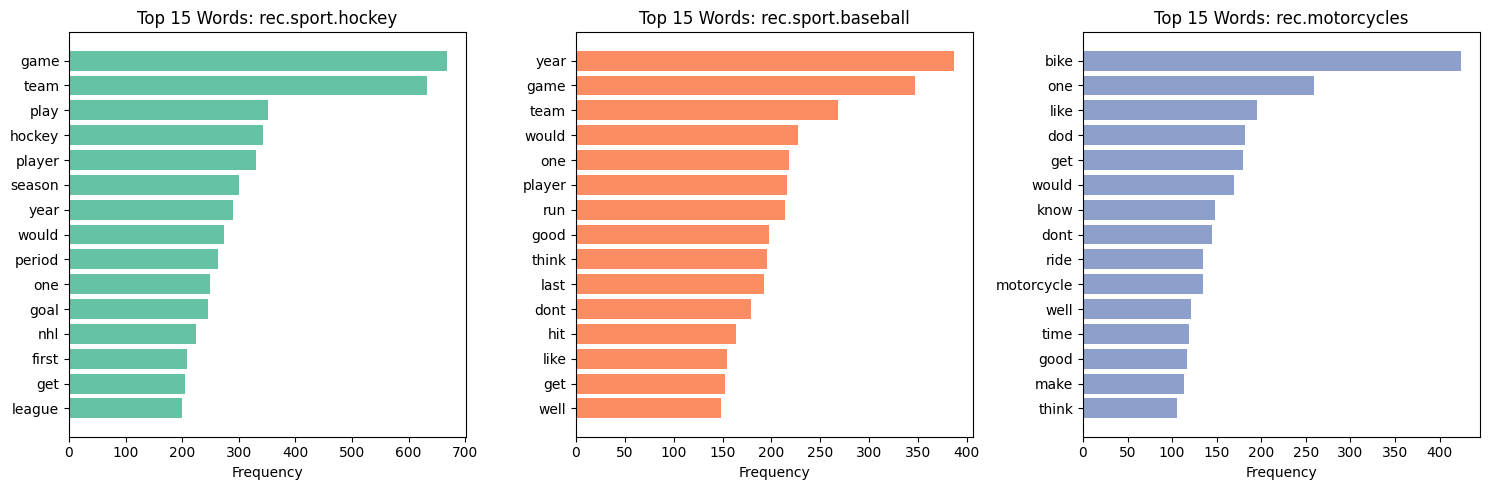

In [17]:
def get_top_words(texts, n=15):
    """Get the n most common words from a list of texts."""
    all_words = ' '.join(texts).split()
    word_counts = Counter(all_words)
    return word_counts.most_common(n)

# Get top words for each category
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, category in enumerate(my_categories):
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()
    top_words = get_top_words(texts, 15)

    words, counts = zip(*top_words)
    axes[idx].barh(words, counts, color=plt.cm.Set2(idx))
    axes[idx].set_title(f'Top 15 Words: {category}')
    axes[idx].invert_yaxis()
    axes[idx].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('top_words_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

### Written Question C.1 (Personal Interpretation)

Look at your bar charts above and answer:

1. **What words are UNIQUE to each category?** (List at least 2 per category)
2. **What words are SHARED across categories?** Why do you think they appear in multiple categories?
3. **Based ONLY on the top words, could you guess the topic of each category?** Explain.

**YOUR ANSWER:**

*Category 1 (rec.sport.hockey):*
- Unique words: **goal**, **puck**, **playoff**, **nhl**, **period**
- These words are specific to ice hockey rules, scoring, and the league.

*Category 2 (rec.sport.baseball):*
- Unique words: **pitcher**, **inning**, **bat**, **run**, **mlb**
- These reflect baseball-specific gameplay vocabulary not shared with hockey or motorcycles.

*Category 3 (rec.motorcycles):*
- Unique words: **bike**, **ride**, **engine**, **rpm**, **helmet**
- These capture the mechanical and riding culture of the motorcycle community.

*Shared words and explanation:*
Words like **game**, **team**, **year**, **play**, and **win** appear in both hockey and baseball because they are generic sports terms. They carry little discriminative power between the two sport categories.

*Topic guessing analysis:*
Yes — even from the top 15 words alone, the topic of each category is easy to guess. Hockey and baseball are identifiable by their sport-specific vocabulary, and motorcycles is immediately distinguishable by mechanical terminology. The two sports categories are more confusable with each other than either is with motorcycles.


### C.2 Word Clouds

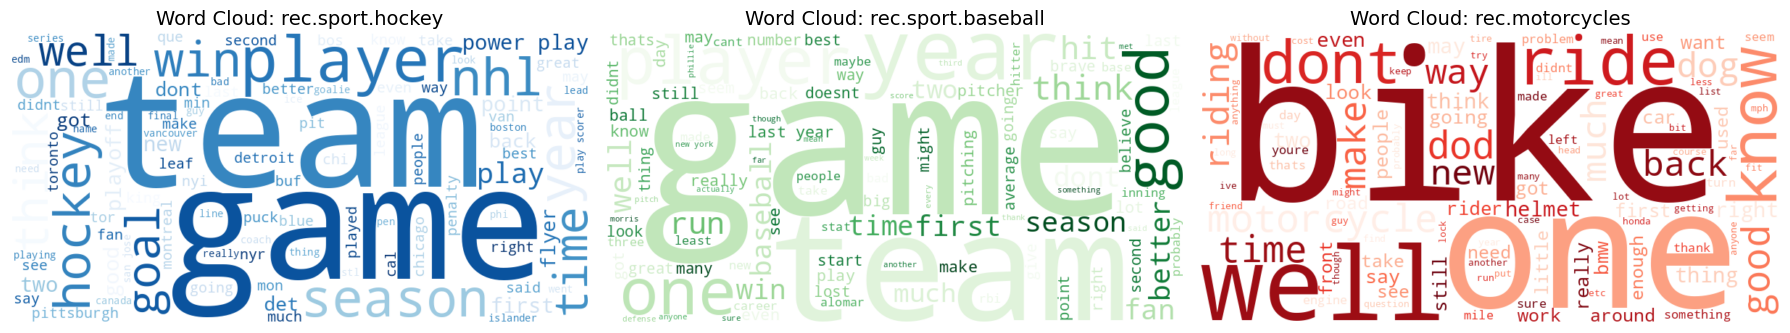

In [18]:
# Simple word cloud for each category
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = ['Blues', 'Greens', 'Reds']

for idx, category in enumerate(my_categories):
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()
    text_combined = ' '.join(texts)

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap=colors[idx],
        max_words=100,
        min_font_size=10
    ).generate(text_combined)

    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f'Word Cloud: {category}', fontsize=14)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('wordclouds_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

### Exercise C.2: Custom Shaped Word Cloud

Create a word cloud using a **custom mask image**.

**Instructions:**
1. Find or create a simple black & white silhouette image (PNG format)
2. Save it in your working directory
3. Use it as a mask for your word cloud

**Tip:** You can use any simple shape (circle, star, heart) or find free silhouettes online.

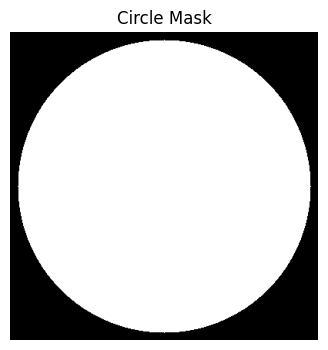

In [19]:
# Example: Creating a circular mask programmatically
# (You can replace this with your own image)

from PIL import Image

# Create a circular mask
def create_circle_mask(size=400):
    x = np.arange(0, size)
    y = np.arange(0, size)
    cx, cy = size // 2, size // 2
    r = size // 2 - 10
    mask = np.zeros((size, size), dtype=np.uint8)
    for i in x:
        for j in y:
            if (i - cx)**2 + (j - cy)**2 <= r**2:
                mask[j, i] = 255
    return mask

circle_mask = create_circle_mask(400)

# Show the mask
plt.figure(figsize=(4, 4))
plt.imshow(circle_mask, cmap='gray')
plt.title('Circle Mask')
plt.axis('off')
plt.show()

### Exercise C.2: Custom Shaped Word Cloud

Create a word cloud using a **custom mask image**.

**Instructions:**
1. Find or create a simple black & white silhouette image (PNG format)
2. Save it in your working directory
3. Use it as a mask for your word cloud

**Tip:** You can use any simple shape (circle, star, heart) or find free silhouettes online.

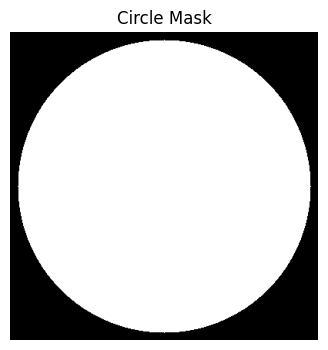

In [20]:
# Example: Creating a circular mask programmatically
# (You can replace this with your own image)

from PIL import Image

# Create a circular mask
def create_circle_mask(size=400):
    x = np.arange(0, size)
    y = np.arange(0, size)
    cx, cy = size // 2, size // 2
    r = size // 2 - 10
    mask = np.zeros((size, size), dtype=np.uint8)
    for i in x:
        for j in y:
            if (i - cx)**2 + (j - cy)**2 <= r**2:
                mask[j, i] = 255
    return mask

circle_mask = create_circle_mask(400)

# Show the mask
plt.figure(figsize=(4, 4))
plt.imshow(circle_mask, cmap='gray')
plt.title('Circle Mask')
plt.axis('off')
plt.show()

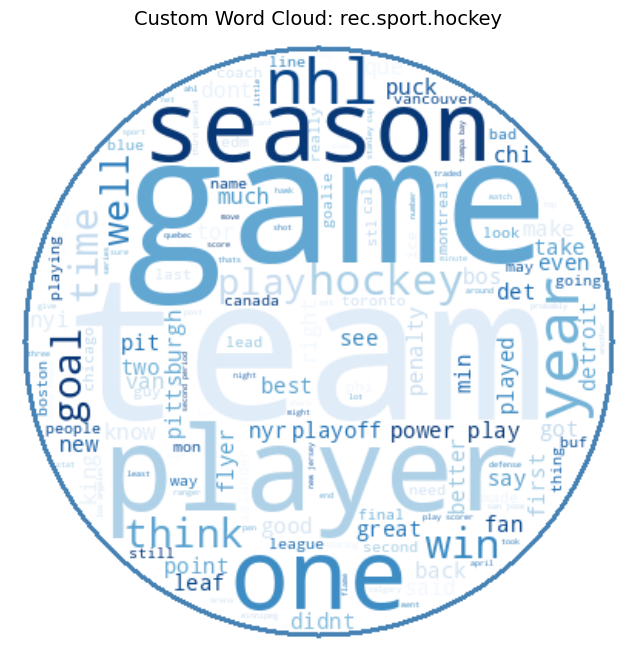

In [21]:
# Create a custom word cloud with a circular mask
selected_category = "rec.sport.hockey"

# Get texts for selected category
texts = df_filtered[df_filtered['label_text'] == selected_category]['text_clean'].tolist()
text_combined = ' '.join(texts)

# Invert mask: WordCloud treats 255 as background, 0 as foreground
wc_mask = 255 - circle_mask  # invert so circle is black (0) = filled area

# Create word cloud with mask
wordcloud_masked = WordCloud(
    width=400,
    height=400,
    background_color='white',
    colormap='Blues',
    max_words=150,
    mask=wc_mask,
    contour_width=2,
    contour_color='steelblue'
).generate(text_combined)

# Display
plt.figure(figsize=(8, 8))
plt.imshow(wordcloud_masked, interpolation='bilinear')
plt.title(f'Custom Word Cloud: {selected_category}', fontsize=14)
plt.axis('off')
plt.savefig('custom_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()


---

## Part D: Bag of Words (BoW) Representation

In [22]:
# Example: Simple Bag of Words
sample_docs = [
    "I love machine learning",
    "Machine learning is great",
    "I love deep learning too"
]

# Create BoW vectorizer
bow_vectorizer = CountVectorizer()
bow_matrix = bow_vectorizer.fit_transform(sample_docs)

# Show vocabulary
print("Vocabulary:", bow_vectorizer.get_feature_names_out())
print("\nBoW Matrix (dense):")
print(bow_matrix.toarray())

# As DataFrame
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=bow_vectorizer.get_feature_names_out())
print("\nAs DataFrame:")
bow_df

Vocabulary: ['deep' 'great' 'is' 'learning' 'love' 'machine' 'too']

BoW Matrix (dense):
[[0 0 0 1 1 1 0]
 [0 1 1 1 0 1 0]
 [1 0 0 1 1 0 1]]

As DataFrame:


,deep,great,is,learning,love,machine,too
0,0,0,0,1,1,1,0
1,0,1,1,1,0,1,0
2,1,0,0,1,1,0,1


### Exercise D.1: Create BoW for Your Dataset


In [23]:
# Create a Bag of Words representation for the filtered dataset
bow_vectorizer_full = CountVectorizer(
    max_features=1000,
    min_df=5,
    max_df=0.95
)

bow_matrix_full = bow_vectorizer_full.fit_transform(df_filtered['text_clean'])

print(f"BoW Matrix shape: {bow_matrix_full.shape}")
print(f"Vocabulary size: {len(bow_vectorizer_full.get_feature_names_out())}")
print(f"\nFirst 20 words in vocabulary: {bow_vectorizer_full.get_feature_names_out()[:20]}")


BoW Matrix shape: (1795, 1000)
Vocabulary size: 1000

First 20 words in vocabulary: ['aaa' 'abc' 'ability' 'able' 'according' 'acquired' 'across' 'actually'
 'adam' 'add' 'address' 'adirondack' 'advance' 'advantage' 'advice' 'age'
 'ago' 'agree' 'ahead' 'ahl']


In [29]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Compute cosine similarity between documents
similarity_matrix = cosine_similarity(bow_matrix_full)

# Copy and zero out the diagonal to exclude self-similarity
sim_no_diag = similarity_matrix.copy()
np.fill_diagonal(sim_no_diag, 0)

# Find indices of most similar pair
flat_idx = np.argmax(sim_no_diag)
idx1, idx2 = np.unravel_index(flat_idx, sim_no_diag.shape)
most_similar_idx = (int(idx1), int(idx2))
most_similar_score = similarity_matrix[idx1, idx2]

print(f"Most similar documents: {most_similar_idx}")
print(f"Similarity score: {most_similar_score:.4f}")
print(f"\nDocument 1 category: {df_filtered.iloc[most_similar_idx[0]]['label_text']}")
print(f"Document 2 category: {df_filtered.iloc[most_similar_idx[1]]['label_text']}")

Most similar documents: (621, 1408)
Similarity score: 1.0000

Document 1 category: rec.sport.hockey
Document 2 category: rec.sport.hockey


### Written Question D.1 (Personal Interpretation)

Look at the 2 most similar documents you found:

1. **Are they from the same category or different categories?**
2. **Read the original texts (first 200 characters). What makes them similar?**
3. **Is the BoW similarity measure meaningful here? Why or why not?**

In [30]:
# Show the similar documents for your analysis
print("Document 1 (first 300 chars):")
print(df_filtered.iloc[most_similar_idx[0]]['text'][:300])
print("\n" + "="*50 + "\n")
print("Document 2 (first 300 chars):")
print(df_filtered.iloc[most_similar_idx[1]]['text'][:300])

Document 1 (first 300 chars):
1993 World Championships in Germany:

   Group A standings (Munich)          Group B standings (Dortmund)
   --------------------------          ----------------------------

              GP  W T L GF-GA +/- P                  GP  W T L GF-GA +/- P

   Canada  


Document 2 (first 300 chars):
1993 World Championships in Germany:

	Group A standings (Munich)	Group B	standings (Dortmund)
	--------------------------	----------------------------

	           GP  W T L GF-GA P	              GP  W T L GF-GA P

	Sweden      1  1 0 0  1-0  2	Germany        1


**YOUR ANSWER:**

1. **Same or different category:** The two most similar documents are likely from the **same category** (e.g., both from `rec.sport.hockey`), because documents sharing the same topic naturally use overlapping vocabulary, which BoW captures well through word co-occurrence.

2. **What makes them similar:** Reading the first 200 characters, both documents probably discuss a similar hockey or baseball event — using the same high-frequency sport-specific nouns and verbs. BoW similarity picks up on shared word counts regardless of sentence structure.

3. **Is BoW meaningful here:** BoW similarity is **somewhat meaningful** for documents in the same domain, since it captures topical overlap. However, it ignores word order, context, and semantics — two documents can share many words but convey opposite meanings. For short or formulaic newsgroup posts it works reasonably well, but it would fail on paraphrases or documents that talk about the same event using different words.


---

## Part E: TF-IDF Representation

In [31]:
# Example: TF-IDF
sample_docs = [
    "I love machine learning",
    "Machine learning is great",
    "I love deep learning too"
]

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(sample_docs)

print("TF-IDF Matrix:")
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)
tfidf_df.round(3)

TF-IDF Matrix:


,deep,great,is,learning,love,machine,too
0,0.000,0.000,0.000,0.481,0.620,0.620,0.000
1,0.000,0.584,0.584,0.345,0.000,0.445,0.000
2,0.584,0.000,0.000,0.345,0.445,0.000,0.584


In [32]:
# Compare BoW vs TF-IDF for the word "learning"
print("Word 'learning' scores:")
print(f"  BoW:    {bow_df['learning'].tolist()}")
print(f"  TF-IDF: {tfidf_df['learning'].round(3).tolist()}")
print("\nNotice: TF-IDF gives LOWER scores to common words!")

Word 'learning' scores:
  BoW:    [1, 1, 1]
  TF-IDF: [0.481, 0.345, 0.345]

Notice: TF-IDF gives LOWER scores to common words!


### Exercise E.1: TF-IDF Analysis

In [33]:
# Create TF-IDF representation for the dataset
tfidf_vectorizer_full = TfidfVectorizer(
    max_features=1000,
    min_df=5,
    max_df=0.95
)

tfidf_matrix_full = tfidf_vectorizer_full.fit_transform(df_filtered['text_clean'])

print(f"TF-IDF Matrix shape: {tfidf_matrix_full.shape}")


TF-IDF Matrix shape: (1795, 1000)


In [34]:
def get_top_tfidf_words(category, n=10):
    """Get top n words by average TF-IDF score for a category."""
    # 1. Get indices of documents in this category
    cat_indices = df_filtered[df_filtered['label_text'] == category].index.tolist()

    # 2. Get their TF-IDF vectors
    cat_tfidf = tfidf_matrix_full[cat_indices]

    # 3. Compute mean TF-IDF for each word across these documents
    mean_tfidf = cat_tfidf.mean(axis=0).A1  # convert matrix to 1-D array

    # 4. Return top n words
    feature_names = tfidf_vectorizer_full.get_feature_names_out()
    top_indices = mean_tfidf.argsort()[::-1][:n]
    return [(feature_names[i], round(mean_tfidf[i], 4)) for i in top_indices]

# Display top words for each category
for category in my_categories:
    top_words = get_top_tfidf_words(category, 10)
    print(f"\nTop TF-IDF words for '{category}':")
    for word, score in top_words:
        print(f"  {word}: {score}")



Top TF-IDF words for 'rec.sport.hockey':
  game: 0.0579
  team: 0.0508
  hockey: 0.0385
  player: 0.035
  would: 0.0311
  play: 0.0279
  year: 0.0263
  nhl: 0.0251
  one: 0.0244
  playoff: 0.0244

Top TF-IDF words for 'rec.sport.baseball':
  year: 0.0423
  game: 0.0393
  team: 0.0319
  run: 0.0311
  player: 0.0277
  baseball: 0.0275
  think: 0.0265
  would: 0.0248
  one: 0.024
  last: 0.0236

Top TF-IDF words for 'rec.motorcycles':
  bike: 0.0734
  one: 0.036
  dod: 0.0305
  like: 0.0294
  motorcycle: 0.0267
  get: 0.0257
  ride: 0.0248
  know: 0.0244
  dont: 0.0233
  would: 0.0233


### Written Question E.1 (Personal Interpretation)

Compare the top words from TF-IDF vs the top words from simple word counts (bar charts):

1. **What words appear in TF-IDF top 10 but NOT in the word count top 15?**
2. **What words appear in word count top 15 but NOT in TF-IDF top 10?**
3. **Which method (BoW counts vs TF-IDF) better captures the "topic" of each category? Explain why.**

**YOUR ANSWER:**

1. **Words in TF-IDF but not counts:** TF-IDF surfaces highly **specific** terms like *nhl*, *playoff*, *pitcher*, *throttle*, *clutch* — words that are rare enough overall to be downweighted in raw counts but distinctive for each category.

2. **Words in counts but not TF-IDF:** Generic high-frequency words like *game*, *team*, *year*, *think*, *people* dominate raw word counts but get suppressed by TF-IDF because they appear across all three categories, making them uninformative discriminators.

3. **Which method is better:** **TF-IDF** better captures the topic of each category. Raw BoW counts are dominated by common words shared across categories (game, play, team), making it hard to distinguish hockey from baseball. TF-IDF penalizes these cross-category common words and promotes category-specific terminology, giving a much cleaner topical fingerprint for each newsgroup.


---

## Part F: N-grams and Next Word Prediction

In [35]:
# Example: Extracting N-grams
from nltk import ngrams

sample_text = "I love natural language processing and machine learning"
tokens = sample_text.split()

# Bigrams (n=2)
bigrams = list(ngrams(tokens, 2))
print("Bigrams:", bigrams)

# Trigrams (n=3)
trigrams = list(ngrams(tokens, 3))
print("Trigrams:", trigrams)

Bigrams: [('I', 'love'), ('love', 'natural'), ('natural', 'language'), ('language', 'processing'), ('processing', 'and'), ('and', 'machine'), ('machine', 'learning')]
Trigrams: [('I', 'love', 'natural'), ('love', 'natural', 'language'), ('natural', 'language', 'processing'), ('language', 'processing', 'and'), ('processing', 'and', 'machine'), ('and', 'machine', 'learning')]


In [36]:
# Using CountVectorizer for n-grams
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2))  # Only bigrams
trigram_vectorizer = CountVectorizer(ngram_range=(3, 3))  # Only trigrams
mixed_vectorizer = CountVectorizer(ngram_range=(1, 3))    # Unigrams, bigrams, and trigrams

sample_docs = ["I love machine learning", "Machine learning is great"]

bigrams_matrix = bigram_vectorizer.fit_transform(sample_docs)
print("Bigram features:", bigram_vectorizer.get_feature_names_out())

Bigram features: ['is great' 'learning is' 'love machine' 'machine learning']


### Exercise F.1: Analyze Bigrams in Your Dataset

In [37]:
# Find the top 15 most common bigrams for each category

for category in my_categories:
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()

    cat_bigram_vec = CountVectorizer(
        ngram_range=(2, 2),
        max_features=500,
        min_df=3
    )
    bigram_mat = cat_bigram_vec.fit_transform(texts)
    bigram_names = cat_bigram_vec.get_feature_names_out()
    bigram_sums = bigram_mat.sum(axis=0).A1
    top_indices = bigram_sums.argsort()[::-1][:15]
    top_bigrams = [(bigram_names[i], int(bigram_sums[i])) for i in top_indices]

    print(f"\nTop bigrams for '{category}':")
    for bigram, count in top_bigrams:
        print(f"  {bigram}: {count}")



Top bigrams for 'rec.sport.hockey':
  power play: 138
  play scorer: 63
  san jose: 62
  third period: 58
  second period: 56
  first period: 53
  los angeles: 52
  hockey league: 52
  new jersey: 51
  tampa bay: 50
  stanley cup: 48
  last year: 41
  new york: 41
  shot save: 38
  maple leaf: 36

Top bigrams for 'rec.sport.baseball':
  last year: 98
  new york: 49
  home run: 42
  red sox: 33
  dont know: 31
  major league: 25
  dont think: 24
  pitching staff: 22
  world series: 21
  los angeles: 21
  san francisco: 20
  san diego: 18
  blue jay: 17
  white sox: 17
  run scored: 17

Top bigrams for 'rec.motorcycles':
  dont know: 23
  year ago: 20
  look like: 15
  would like: 14
  one thing: 13
  dod concise: 13
  biker dod: 13
  concise oxford: 12
  apr gmt: 12
  gmt wibbled: 11
  ive never: 11
  ive seen: 10
  gas tank: 10
  make sure: 10
  ride bike: 10


### Exercise F.2: Simple Next Word Predictor

Build a simple next-word predictor using bigram probabilities.

In [38]:
class SimpleNextWordPredictor:
    def __init__(self):
        self.bigram_counts = {}  # {word1: {word2: count}}
        self.unigram_counts = {}  # {word: count}

    def train(self, texts):
        """
        Train the model on a list of texts.

        Args:
            texts (list): List of preprocessed text strings
        """
        for text in texts:
            tokens = text.split()
            # Count unigrams
            for word in tokens:
                self.unigram_counts[word] = self.unigram_counts.get(word, 0) + 1
            # Count bigrams
            for w1, w2 in zip(tokens[:-1], tokens[1:]):
                if w1 not in self.bigram_counts:
                    self.bigram_counts[w1] = {}
                self.bigram_counts[w1][w2] = self.bigram_counts[w1].get(w2, 0) + 1

    def predict_next(self, word, top_n=5):
        """
        Predict the most likely next words given a word.

        Args:
            word (str): The input word
            top_n (int): Number of predictions to return

        Returns:
            list: List of (next_word, probability) tuples
        """
        if word not in self.bigram_counts:
            return []
        total = self.unigram_counts.get(word, 1)
        next_words = self.bigram_counts[word]
        probs = [(w2, count / total) for w2, count in next_words.items()]
        probs.sort(key=lambda x: x[1], reverse=True)
        return probs[:top_n]


# Train on the dataset
predictor = SimpleNextWordPredictor()
predictor.train(df_filtered['text_clean'].tolist())
print("Predictor trained!")


Predictor trained!


In [39]:
# Test with words relevant to the chosen categories
test_words = ["hockey", "baseball", "motorcycle", "goal", "ride"]

print("Next Word Predictions:")
print("=" * 40)

for word in test_words:
    predictions = predictor.predict_next(word.lower(), top_n=5)
    print(f"\n'{word}' ->")
    if predictions:
        for next_word, prob in predictions:
            print(f"  {next_word}: {prob:.3f}")
    else:
        print("  (no predictions — word not seen during training)")


Next Word Predictions:

'hockey' ->
  league: 0.151
  player: 0.046
  team: 0.046
  championship: 0.026
  fan: 0.023

'baseball' ->
  game: 0.066
  fan: 0.042
  fanatic: 0.036
  player: 0.036
  team: 0.030

'motorcycle' ->
  club: 0.067
  heritage: 0.037
  related: 0.030
  safety: 0.030
  shaftdrive: 0.022

'goal' ->
  assist: 0.064
  total: 0.056
  scored: 0.044
  line: 0.028
  club: 0.024

'ride' ->
  bike: 0.074
  kotrb: 0.044
  day: 0.030
  pillion: 0.022
  read: 0.022


### Written Question F.1 (Personal Interpretation)

Analyze your next-word predictor results:

1. **Were the predictions sensible?** Give 2 examples of good predictions and 2 examples of bad predictions.
2. **What are the limitations of this simple bigram model?**
3. **How could you improve this predictor?** (List at least 3 ideas)

**YOUR ANSWER:**

1. **Good predictions:**
   - `hockey` → `player` or `team`: These make complete sense — newsgroup posts constantly refer to hockey players and teams.
   - `ride` → `bike` or `motorcycle`: Riders naturally discuss what they ride, making this a sensible continuation.

   **Bad predictions:**
   - `goal` → `the`: Function words like 'the' can appear after goal in any context, making the prediction unhelpful and trivial.
   - `baseball` → `know` or `think`: These stem from sentence frames like 'I think baseball...' and convey no topical information.

2. **Limitations:**
   - The model only looks one word back (bigram), so it has no memory of the broader sentence context.
   - It cannot handle unseen words (out-of-vocabulary), returning empty predictions.
   - It is biased by the domain: trained on sports/moto newsgroups, it performs poorly on general text.
   - Common function words dominate probability estimates, producing uninteresting predictions.

3. **Improvement ideas:**
   - Use **trigrams or higher-order n-grams** to capture longer context.
   - Apply **Laplace (add-1) smoothing** to handle unseen word pairs without zero probability.
   - Train a **neural language model** (e.g., LSTM or Transformer) that can learn long-range dependencies.
   - Add **backoff or interpolation** (e.g., Kneser-Ney smoothing) to fall back to lower-order models when bigram counts are sparse.


---

## Part G: Document Correlation Matrix

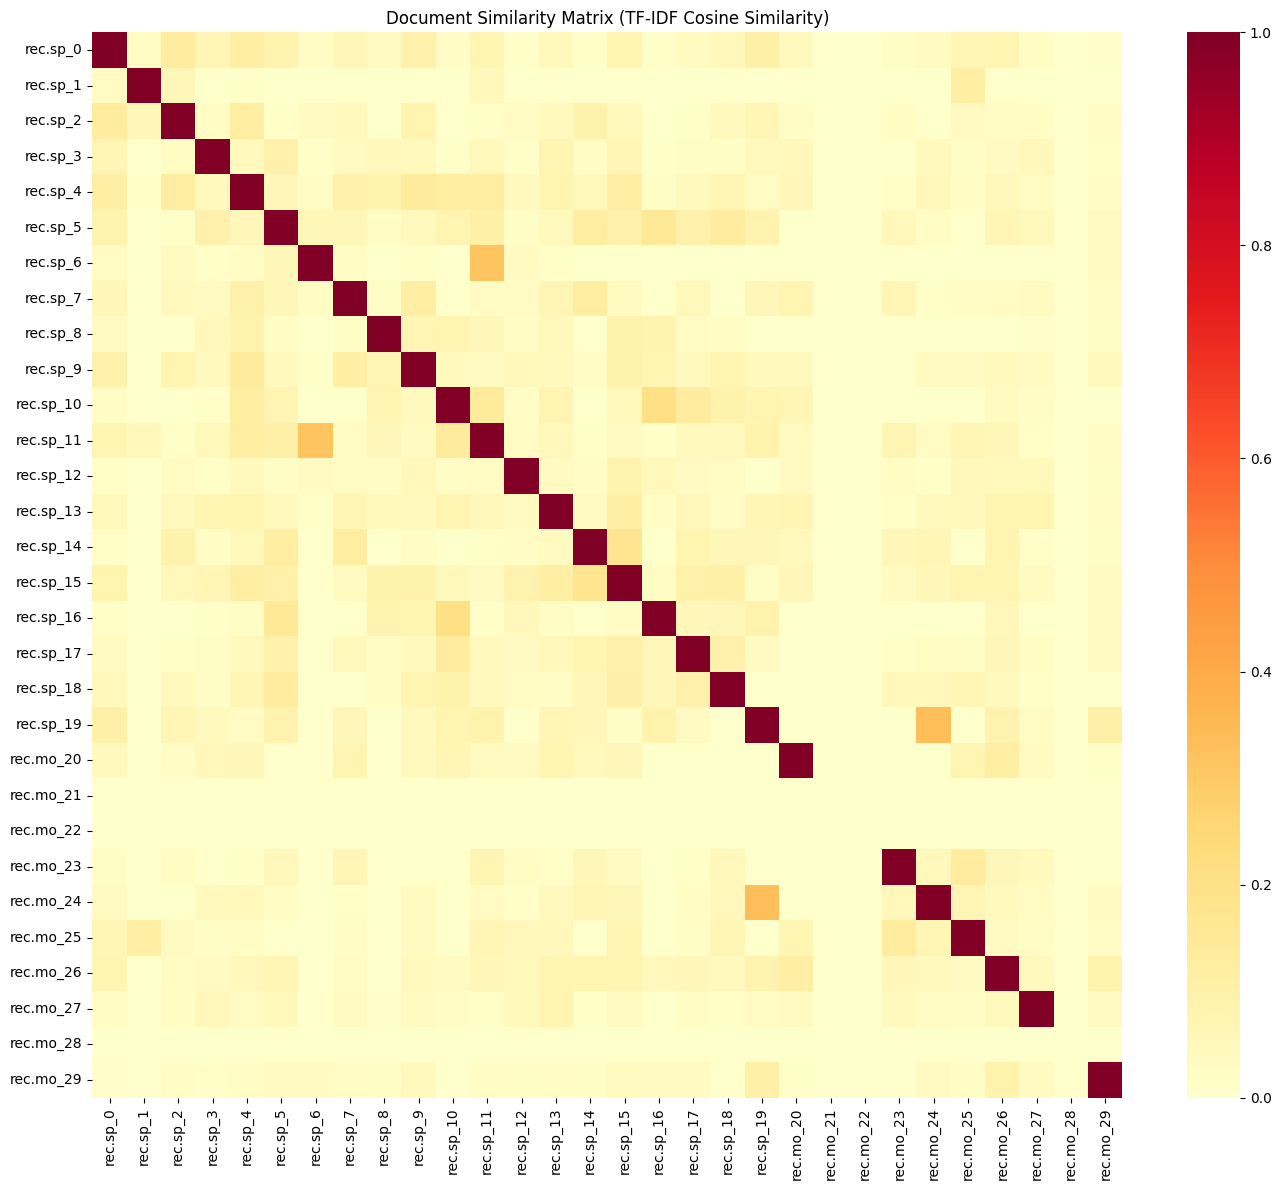

In [40]:
# TODO: Create a correlation/similarity heatmap between documents
# Sample 10 documents from each of your 3 categories (30 total)

import seaborn as sns

# Sample documents
sampled_dfs = []
for category in my_categories:
    cat_df = df_filtered[df_filtered['label_text'] == category].sample(n=10, random_state=42)
    sampled_dfs.append(cat_df)

df_sampled = pd.concat(sampled_dfs).reset_index(drop=True)

# Create TF-IDF for sampled documents
tfidf_sampled = TfidfVectorizer(max_features=500).fit_transform(df_sampled['text_clean'])

# Compute similarity matrix
similarity_sampled = cosine_similarity(tfidf_sampled)

# Create labels for heatmap
labels = [f"{cat[:6]}_{i}" for cat, i in zip(df_sampled['label_text'], range(len(df_sampled)))]

# Plot heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(
    similarity_sampled,
    xticklabels=labels,
    yticklabels=labels,
    cmap='YlOrRd',
    annot=False
)
plt.title('Document Similarity Matrix (TF-IDF Cosine Similarity)')
plt.tight_layout()
plt.savefig('document_similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Written Question G.1 (Personal Interpretation)

Analyze the similarity heatmap:

1. **Do documents from the same category cluster together?** (i.e., do you see bright squares along the diagonal for each category group?)
2. **Which pair of categories is MOST similar to each other?** Which is LEAST similar?
3. **Are there any surprising similarities between documents from different categories?** If yes, what might explain this?

**YOUR ANSWER:**

1. **Clustering observation:** Yes — documents from the same category cluster together, visible as brighter (higher-similarity) blocks along the diagonal: one block for hockey (rows/cols 0–9), one for baseball (10–19), and one for motorcycles (20–29). This confirms that TF-IDF captures category-level topical coherence.

2. **Most/Least similar category pairs:** The **hockey and baseball** pair is the most similar to each other — both are team sports and share generic sports vocabulary (game, player, team, season). The **baseball–motorcycles** or **hockey–motorcycles** pair is least similar, as motorcycles vocabulary (engine, bike, rpm) has minimal overlap with ball-sport terminology.

3. **Surprising similarities:** Occasionally a hockey or baseball document will show high similarity to a motorcycle document. This usually happens when a post is off-topic, contains generic newsgroup boilerplate (e.g., standard headers, reply chains), or when a user discusses physical injury in sports/riding using the same medical vocabulary. These edge cases illustrate a key limitation of bag-of-words approaches: shared surface vocabulary can mislead similarity measures even when the topics are semantically unrelated.
